In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import matplotlib.pyplot as plt
import spacy
nlp = spacy.load("en_core_web_sm")

In [2]:
dr = pd.read_pickle('data/dr/dr_preprocessed.pkl')

In [3]:
# Load spaCy model with unused components disabled
nlp = spacy.load(
    "en_core_web_sm",
    disable=["parser", "ner"]
)

# Set max length once (good practice)
nlp.max_length = 2_000_000


def word_freq(df, column, top_n=30):
    """
    Plot top-N most common nouns and verbs from a dataframe text column.
    Optimized for very large corpora (millions of tokens).
    """

    # Convert column to list of strings (one doc per row)
    texts = df[column].dropna().astype(str).tolist()

    noun_counts = Counter()
    verb_counts = Counter()

    # Process documents in batches with multiprocessing
    for doc in nlp.pipe(
        texts,
        batch_size=1000,
        n_process=4  # adjust to number of CPU cores
    ):
        for token in doc:
            if not token.is_alpha:
                continue

            if token.pos_ == "NOUN":
                noun_counts[token.lemma_.lower()] += 1
            elif token.pos_ == "VERB":
                verb_counts[token.lemma_.lower()] += 1

    # Get most common items
    noun_common = noun_counts.most_common(top_n)
    verb_common = verb_counts.most_common(top_n)

    if not noun_common or not verb_common:
        raise ValueError("No nouns or verbs found in the data.")

    noun_words, noun_freqs = zip(*noun_common)
    verb_words, verb_freqs = zip(*verb_common)
    
    return noun_words, noun_freqs, verb_words, verb_freqs

In [4]:
top_n = 30

# Group by launch_year and apply word_freq function to each group
yearly_results = {}

for year in dr['launch_year'].unique():
    # Filter data for the specific year
    year_data = dr[dr['launch_year'] == year]
    
    # Skip if no data for this year
    if len(year_data) == 0:
        continue
        
    # Apply word_freq function to the "description" column for this year
    try:
        noun_words, noun_freqs, verb_words, verb_freqs = word_freq(year_data, "description", top_n)
        yearly_results[year] = {
            'nouns': (noun_words, noun_freqs),
            'verbs': (verb_words, verb_freqs)
        }
            
    except Exception as e:
        print(f"Error processing year {year}: {e}")
        continue

# Create DataFrames to compare across years
import pandas as pd

# For nouns
noun_df = pd.DataFrame()

for year, results in yearly_results.items():
    noun_words, noun_freqs = results['nouns']
    total_nouns = sum(noun_freqs)
    for word, freq in zip(noun_words, noun_freqs):
        # Store as percentage
        noun_df.loc[word, str(year)] = (freq / total_nouns) * 100

noun_df = noun_df.fillna(0)

# For verbs
verb_df = pd.DataFrame()

for year, results in yearly_results.items():
    verb_words, verb_freqs = results['verbs']
    total_verbs = sum(verb_freqs)
    for word, freq in zip(verb_words, verb_freqs):
        # Store as percentage
        verb_df.loc[word, str(year)] = (freq / total_verbs) * 100

verb_df = verb_df.fillna(0)

# Sort columns (years) in ascending order
noun_df = noun_df[sorted(noun_df.columns, key=int)]
verb_df = verb_df[sorted(verb_df.columns, key=int)]

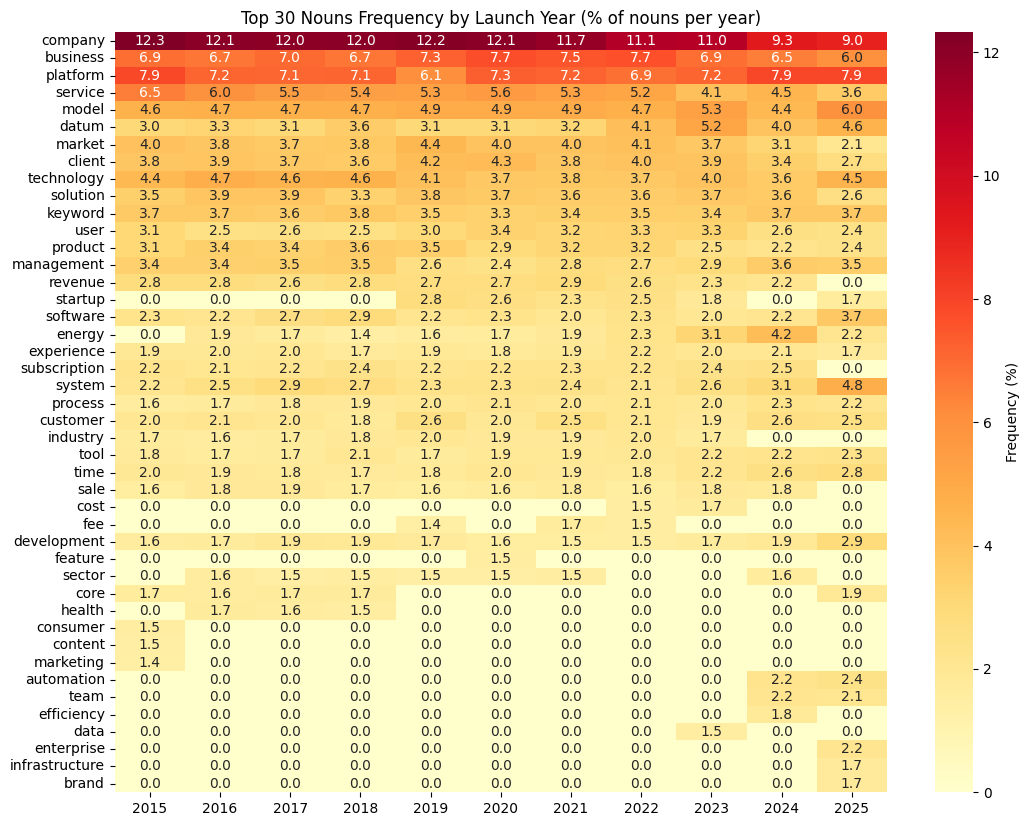

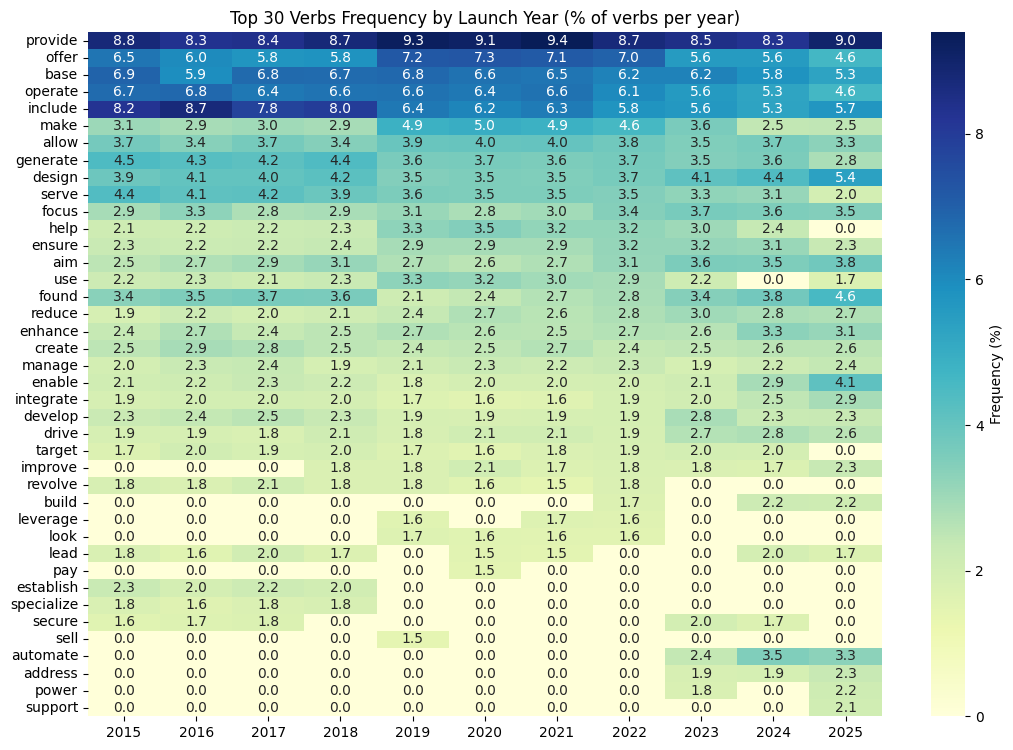

In [5]:
# Optional: Visualize as heatmaps
import matplotlib.pyplot as plt
import seaborn as sns

# Parameters to make cells bigger (and fonts more readable)
cell_width = 1  # approximate width of each column in inches
cell_height = 0.19  # approximate height of each row in inches
fontsize = 10

# Plot nouns heatmap (percentages)
if not noun_df.empty:
    plt.figure(figsize=(len(noun_df.columns)*cell_width, len(noun_df)*cell_height))
    sns.heatmap(
        noun_df,
        annot=True,
        fmt='.1f',
        cmap='YlOrRd',
        cbar_kws={'label': 'Frequency (%)'}
    )
    plt.xticks(fontsize=fontsize)
    plt.yticks(fontsize=fontsize)
    plt.title(f'Top {top_n} Nouns Frequency by Launch Year (% of nouns per year)', fontsize=fontsize+2)
    plt.tight_layout()
    plt.savefig('plots/noun_frequency_by_year.pdf', dpi=300)
    plt.show()

# Plot verbs heatmap (percentages)
if not verb_df.empty:
    plt.figure(figsize=(len(verb_df.columns)*cell_width, len(verb_df)*cell_height))
    sns.heatmap(
        verb_df,
        annot=True,
        fmt='.1f',
        cmap='YlGnBu',
        cbar_kws={'label': 'Frequency (%)'}
    )
    plt.xticks(fontsize=fontsize)
    plt.yticks(fontsize=fontsize)
    plt.title(f'Top {top_n} Verbs Frequency by Launch Year (% of verbs per year)', fontsize=fontsize+2)
    plt.tight_layout()
    plt.savefig('plots/verb_frequency_by_year.pdf', dpi=300)
    plt.show()